# Doğrusal SVM - Linear SVM Sınıflandırma ve Karesel Programlama 

Doğrusal karar sınırlarına sahip SVM modelleri, Scikit-Learn kütüphanesi ve Karesel Programlama (Quadratic Programming - QP) matris dönüşümlerinin incelenmesi.

##  Destek Vektörleri ile Sınır Hesaplama Örneği

- **Örnek veri noktaları:**
  - Pozitif sınıf etiketli ($y = +1$) veri noktası: $A(2, 2)$
  - Negatif sınıf etiketli ($y = -1$) veri noktası: $B(0, 0)$

Bu iki noktanın marj sınırlarının tam üzerinde yer aldığı, yani **Destek Vektörleri** olduğu varsayılmakta. Bu durumda şu sınır denklemleri kurulabilir:
1. Pozitif sınıf için sınır: $w_1 x_1 + w_2 x_2 + b = 1$
2. Negatif sınıf için sınır: $w_1 x_1 + w_2 x_2 + b = -1$

### Katsayıların Hesaplanması

1. **B(0,0) noktasının negatif sınır denklemine yazılması:**
   $$w_1(0) + w_2(0) + b = -1 \implies b = -1$$

2. **A(2,2) noktasının pozitif sınır denklemine yazılması (ve $b = -1$ değerinin yerine konması):**
   $$w_1(2) + w_2(2) - 1 = 1 \implies 2w_1 + 2w_2 = 2 \implies w_1 + w_2 = 1$$

3. **Normu Minimize Etme:**
   SVM'in amacı ağırlık vektörünün uzunluğunun karesini ($\min \|w\|^2 = w_1^2 + w_2^2$) minimize etmektir. Toplamları $1$ olan iki sayının karelerinin toplamının minimum olması için bu iki sayının birbirine eşit olması gerekir:
   $$w_1 = 0.5, \quad w_2 = 0.5$$

   Buradan ağırlık vektörü $w = [0.5, 0.5]^T$ ve bias $b = -1$ olarak elde edilir.

4. **Karar Sınırı Denklemi ($w^T x + b = 0$):**
   $$0.5x_1 + 0.5x_2 - 1 = 0 \implies x_1 + x_2 = 2$$

5. **Marj Genişliğinin Hesabı:**
   $$\|w\| = \sqrt{w_1^2 + w_2^2} = \sqrt{0.5^2 + 0.5^2} = \sqrt{0.5} \approx 0.707$$
   $$\text{Marj Genişliği} = \frac{2}{\|w\|} = \frac{2}{0.707} \approx 2.82 \quad (\text{yani } 2\sqrt{2})$$

## Karar Doğrusunun Çizimi 

Grafik çizerken $w_1 x_1 + w_2 x_2 + b = 0$ doğrusunun koordinat sisteminde gösterilmesi gerekir. Genelde dikey eksen $y$ ($x_2$) ve yatay eksen $x$ ($x_1$) olarak kabul edilirse, denklem şu şekilde düzenlenir:

$$w_1 x + w_2 y + b = 0 \implies w_2 y = -(w_1 x + b) \implies y = -\frac{w_1 x + b}{w_2}$$

Matplotlib ile grafik çizerken karar doğrusunun $y$ koordinat değerleri bu formül üzerinden hesaplanır.

## Genel Karesel Programlama - Quadratic Programming - QP Matris Gösterimi

Karesel programlama problemleri genel matris formatı:
$$\min_{p} \frac{1}{2} p^T H p + f^T p \quad \text{s.t.} \quad A p \le b$$

SVM'in primal formunu bu genel QP çözücülere ($p$ vektörü olarak) yerleştirmek için değişkenleri ve katsayı matrislerini şu şekilde eşleştirilir:
- **Değişkenler vektörü ($p$):** Bias ve ağırlıkları birleştirir: $p = [b, w_1, w_2, \dots, w_d]^T$
- **İkinci derece katsayılar matrisi ($H$):** Bias $b$ parametresinin minimize edilmesini engellemek için sol üst köşeye $0$ koyulur, ağırlıklar için birim matris yerleştirilir:
  $$H = \begin{bmatrix} 0 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}$$
- **Lineer katsayılar vektörü ($f$):** Amaç fonksiyonunda doğrusal kısım olmadığı için sıfır vektörüdür: $f = [0, 0, 0]^T$
- **Kısıt matrisi ($A$):** Kısıtların yönünü $\le$ formatına çevirmek için denklem eksi ile çarpılır: $-y_i(w^T x_i + b) \le -1$. Böylece:
  $$A_i = [-y_i, -y_i x_{i,1}, -y_i x_{i,2}]$$
- **Kısıt sağ taraf vektörü ($b$):** Her satır için sabit $-1$ değerlerinden oluşur.

### Matrislerle İkinci Dereceden Form Yazımı

Bir optimizasyon probleminde ikinci dereceden kısmın amaç fonksiyonu $3x^2 + 2xy + 5y^2$ olsun. Bunu $\frac{1}{2} p^T H p$ matris formatında yazmak için katsayılar ikiye bölünerek matrise yerleştirilir:

$$p = \begin{bmatrix} x \\ y \end{bmatrix}$$
$$\frac{1}{2} \begin{bmatrix} x & y \end{bmatrix} \begin{bmatrix} 6 & 2 \\ 2 & 10 \end{bmatrix} \begin{bmatrix} x \\ y \end{bmatrix} = \frac{1}{2} \left( x(6x + 2y) + y(2x + 10y) \right) = 3x^2 + 2xy + 5y^2$$

Dolayısıyla bu ifadenin katsayılar matrisi $H = \begin{bmatrix} 6 & 2 \\ 2 & 10 \end{bmatrix}$ olur.

## Hinge Loss ve Maliyet Fonksiyonu

SVM sınıflandırma modelinin hata fonksiyonu **Hinge Loss** olarak adlandırılır:
$$\text{Maliyet} = \max(0, 1 - t)$$

Burada $t = y_i (w^T x_i + b)$ ifadesi yer alıyor. Bu fonksiyonun çalışma mantığı :
- $t \ge 1$: Veri doğru sınıfta ve marj sınırının dışında kalır. Bu durumda hata sıfır olur.
- $t < 1$: Veri ya marjın içinde kalır ya da yanlış tarafa geçmiştir. Sınır ihlali arttıkça hata doğrusal olarak artar.

Modelin toplam maliyet fonksiyonu :
$$J(w, b) = \frac{1}{2} \|w\|^2 + C \sum_{i=1}^m \max\left(0, 1 - y_i (w^T x_i + b)\right)$$

##  LinearSVC Uygulaması

Scikit-Learn kütüphanesi ile gerçekleştirilen doğrusal sınıflandırma işlemi:

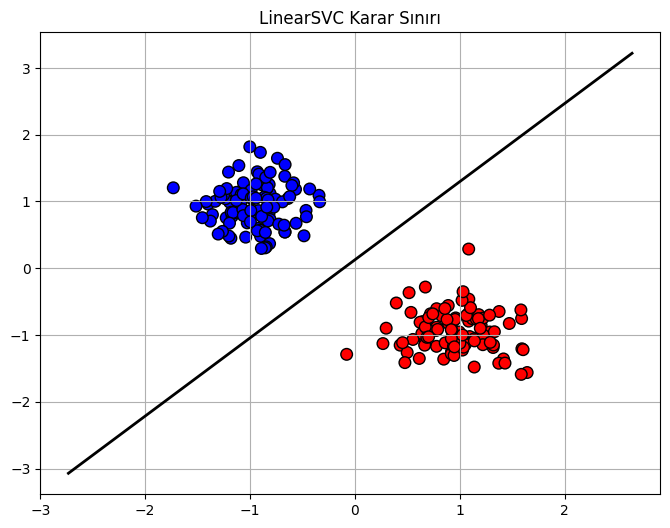

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

# Veri seti oluşturma
X, y = make_blobs(n_samples=200, centers=2, cluster_std=1.2, random_state=42)

# Ölçeklendirme (SVM için kritik öneme sahiptir)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# LinearSVC modelinin kurulması (loss='hinge' parametresi dual=True ile kullanılmalıdır)
model = LinearSVC(C=1.0, loss='hinge', dual=True, random_state=42)
model.fit(X_scaled, y)

# Karar sınırının çizilmesi
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
x_val = np.linspace(x_min, x_max, 200)
w = model.coef_[0]
b = model.intercept_[0]
y_val = -(w[0] * x_val + b) / w[1]

plt.figure(figsize=(8, 6))
plt.plot(x_val, y_val, color="black", linewidth=2, label="Decision Boundary")
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap="bwr", edgecolors="black", s=70)
plt.title("LinearSVC Karar Sınırı")
plt.grid(True)
plt.show()


## Büyük Verilerde Online SVM - SGDClassifier

Eğer veri kümesi bilgisayar belleğine  sığmayacak kadar büyükse, standart QP çözücüler yerine gradyan inişi - Stochastic Gradient Descent - tabanlı **SGDClassifier** kullanılır. Bu model verileri tek tek veya küçük gruplar -- mini-batch -- halinde işler.

In [3]:
from sklearn.linear_model import SGDClassifier

# loss='hinge' parametresi SGDClassifier'ı doğrusal bir SVM modeli gibi çalışmaya zorlar
sgd_svm = SGDClassifier(loss='hinge', alpha=0.01, max_iter=1000, random_state=42)
sgd_svm.fit(X_scaled, y)

print("SGD SVM Katsayıları (w):", sgd_svm.coef_)
print("SGD SVM Bias (b):", sgd_svm.intercept_)

SGD SVM Katsayıları (w): [[ 1.06139451 -0.8579835 ]]
SGD SVM Bias (b): [0.17523333]
